# Kaggle Compititation NoteBook

- Author: Mian Abdul Basit 
- linkedln: 
- Github: https://github.com/mianabdulbasit-tech/Data-Science-And-AI

# Servival Rate Predicted By Neural Network in Tensorflow

In [122]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [123]:
# load the data
df_train = pd.read_csv("data/train.csv")
df_test = pd.read_csv("data/test.csv")
submission = pd.read_csv("data/gender_submission.csv")

In [124]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [125]:
df_test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [126]:
submission.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


# Let's explore the data df_train.csv

In [127]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [128]:
(df_train.isnull().sum() / len(df_train) * 100).sort_values(ascending=False)

Cabin          77.104377
Age            19.865320
Embarked        0.224467
PassengerId     0.000000
Name            0.000000
Pclass          0.000000
Survived        0.000000
Sex             0.000000
Parch           0.000000
SibSp           0.000000
Fare            0.000000
Ticket          0.000000
dtype: float64

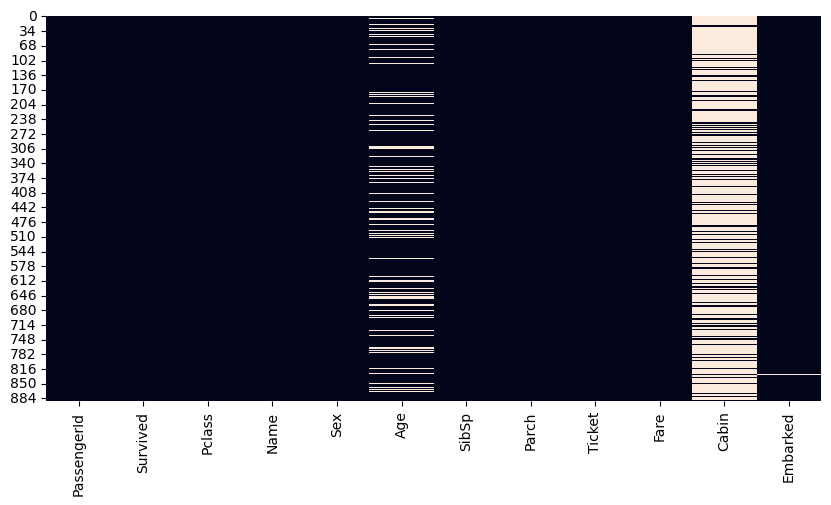

In [129]:
# plot the null values 
plt.figure(figsize=(10, 5))
sns.heatmap(df_train.isnull(), cbar=False)
plt.show()

In [130]:
df_train.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [131]:
df = df_train.copy()

In [132]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Function to Impute the missing values from df

In [133]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, accuracy_score, precision_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['Embarked', 'Cabin']
bool_cols = []
numeric_cols = ['Age']

missing_data_cols = df.isnull().sum()[df.isnull().sum() > 0].index.tolist()

# define the function to impute the missing vaalues 
def impute_categorical_missing_data(df, target_column):
    """
    Fill missing values in any column using Machine Learning.

    Parameters:
        df : DataFrame
        target_column : Column whose missing values are to be filled

    Returns:
        DataFrame with missing values imputed
    """

    if df is None:
        raise ValueError("DataFrame is None. Please pass a valid DataFrame.")

    df = df.copy()

    # Encode object columns
    encoders = {}

    for col in df.select_dtypes(include=['object', 'category']).columns:
        le = LabelEncoder()
        df[col] = df[col].astype(str)
        df[col] = le.fit_transform(df[col])
        encoders[col] = le

    # Separate known and missing rows
    train_data = df[df[target_column].notnull()]
    test_data = df[df[target_column].isnull()]

    # If no missing values
    if len(test_data) == 0:
        print(f"No missing values found in '{target_column}'")
        return df

    # Features
    X_train = train_data.drop(columns=[target_column])
    y_train = train_data[target_column]

    X_test = test_data.drop(columns=[target_column])

    # Select model
    if y_train.dtype == 'object' or y_train.nunique() < 15:
        model = RandomForestClassifier(random_state=42)
    else:
        model = RandomForestRegressor(random_state=42)

    # Train
    model.fit(X_train, y_train)

    # Predict missing values
    predicted_values = model.predict(X_test)

    # Fill missing values
    df.loc[df[target_column].isnull(), target_column] = predicted_values

    return df

# Impute missing values for each column

for col in missing_data_cols:
    df = impute_categorical_missing_data(df, col)

(df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

No missing values found in 'Cabin'
No missing values found in 'Embarked'


PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Cabin          0.0
Embarked       0.0
dtype: float64

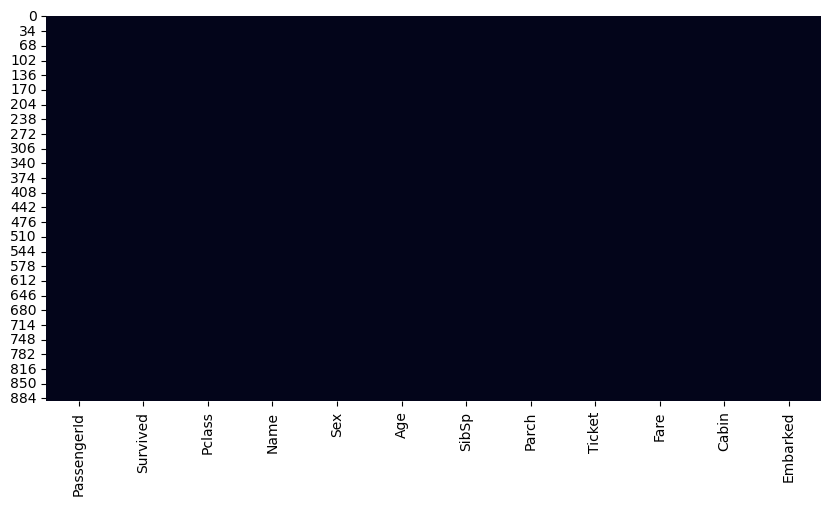

In [134]:
# plot the null values 
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False)
plt.show()

Missing values have been imputed or removed from tha dataset.

In [135]:
# split the data into X and y
X = df.drop(['Survived', 'Name'], axis=1)
y = df['Survived']

# encode the data
label_encoder = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object' or X[col].dtype == 'category':
        X[col] = label_encoder.fit_transform(X[col])

    else:
        pass

# split the data into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state = 42)



In [136]:
X_train.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
331,332,1,1,45.5,0,0,20,28.5000,56,2
733,734,2,1,23.0,0,0,228,13.0000,147,2
382,383,3,1,32.0,0,0,665,7.9250,147,2
704,705,3,1,26.0,1,0,398,7.8542,147,2
813,814,3,0,6.0,4,2,333,31.2750,147,2


# Create a Neural Network for Binary Clasiification

In [137]:
# used tensorflow to create a neural network
import tensorflow as tf


# builting the model
model = tf.keras.models.Sequential([
        tf.keras.layers.Dense(128, activation='relu', 
        input_shape=(X_train.shape[1],)), # input layers

        tf.keras.layers.Dense(64, activation='relu'), # hiden layers
        tf.keras.layers.Dense(32, activation='relu'), # hiden layers
        tf.keras.layers.Dense(16, activation='relu'), # hiden layers
        tf.keras.layers.Dense(8, activation='relu'), # hiden layers

        tf.keras.layers.Dense(1, activation='sigmoid') # output layer
])


c:\Users\Zone Tech\.conda\envs\tensorflow_env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [138]:
# # compile the model
# model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# # train the model
# model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=1)

# # Evaluting the model on the test set
# loss = model.evaluate(X_test, y_test, verbose=1)
# loss

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - accuracy: 0.6067 - loss: 1.2797 - val_accuracy: 0.6257 - val_loss: 0.7815
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6166 - loss: 0.8114 - val_accuracy: 0.6648 - val_loss: 0.6538
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6503 - loss: 0.7034 - val_accuracy: 0.5196 - val_loss: 0.7749
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6699 - loss: 0.6365 - val_accuracy: 0.5866 - val_loss: 0.7153
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6728 - loss: 0.6580 - val_accuracy: 0.6704 - val_loss: 0.6181
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6854 - loss: 0.6207 - val_accuracy: 0.6983 - val_loss: 0.6363
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6601 - loss: 0.6870 - val_accuracy: 0.4637 - val_loss: 0.9071
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5871 - loss: 0.7403 - val_accuracy: 0

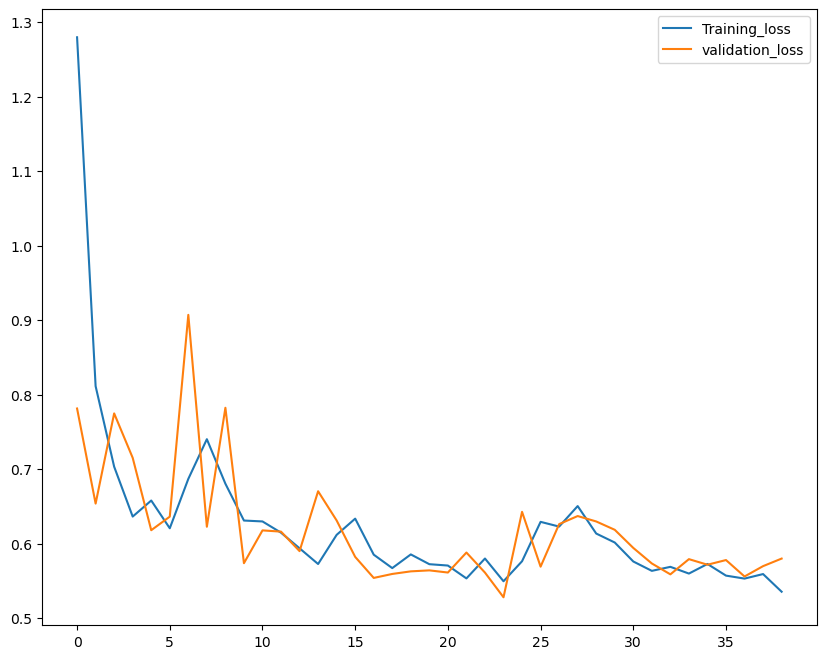

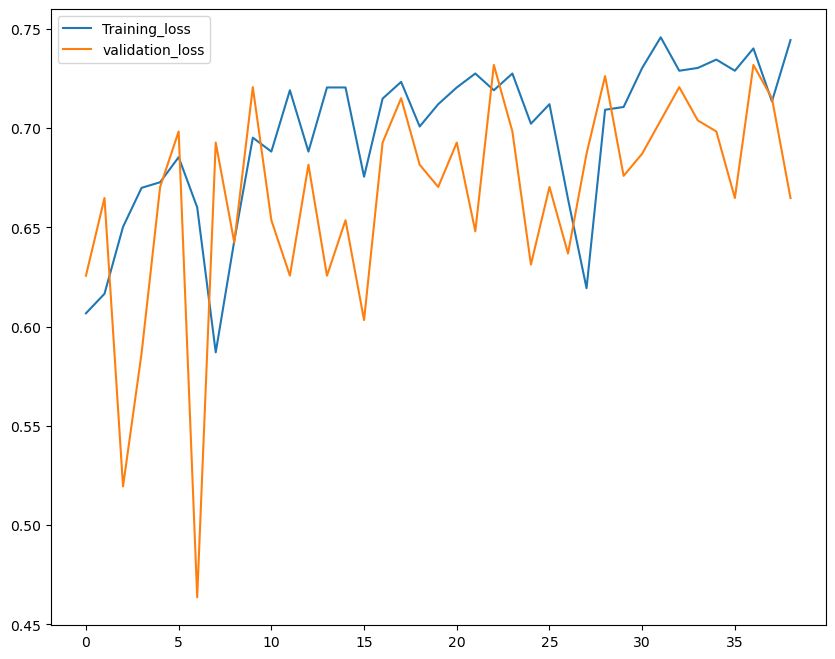

In [139]:
from tensorflow.keras.callbacks import EarlyStopping


# compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

#  Define the callback function
early_stopping = EarlyStopping(patience=15)

# train the model
history = model.fit(X_train, y_train, 
                    epochs=100, batch_size=32, verbose=1, 
                    validation_data=(X_test, y_test),
                    callbacks=[early_stopping])

# plot the training and testing loss and accuracy
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(history.history['loss'], label='Training_loss')
ax.plot(history.history['val_loss'], label='validation_loss')
plt.legend()
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(history.history['accuracy'], label='Training_loss')
ax.plot(history.history['val_accuracy'], label='validation_loss')
plt.legend()
plt.show()

# Try a Traditional Machine Learning Model
You can replace the neural network section with a classical model such as Random Forest or Logistic Regression. These models usually work well for tabular data like this Titanic dataset.

In [141]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Build a Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred = rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.8491620111731844
              precision    recall  f1-score   support

           0       0.85      0.90      0.87       105
           1       0.84      0.78      0.81        74

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179

